# Exploring sampled gist

- based on the experiments from done on bert experiment with different values of nlist, k, and calibration data size

In [10]:
# configuration constants
ALPHA = 0.1
CALIB_SIZE=0.7
DATASET = "gist30k"

# NLIST_GEN_LOWER_BOUND = 70000 # 5000
# NLIST_GEN_UPPER_BOUND = 100000 # 55000
# NLIST_GEN_NUMBER_STEPS = 3 # 50

# K_LOWER_BOUND = 100 # 20
# K_UPPER_BOUND = 600 # 1020
# K_NUMBER_STEPS = 5 # 50

range_nlist = [50, 111, 150, 180, 250]
range_nlist_computed = []
range_calib = [0.9, 0.7, 0.5, 0.3, 0.1]
range_k = [100, 300, 500]

In [2]:
range_nlist_to_compute = list(set(range_nlist) - set(range_nlist_computed))
range_nlist_to_compute.sort()
range_nlist_to_compute

[50, 111, 150, 180, 250]

In [3]:
import subprocess
import os

env = os.environ.copy()
env["OMP_NUM_THREADS"] = "8"

def run_conann(dataset, calib, alpha, nlist, k):
    print("running conann on: ", dataset, calib, alpha, nlist, k)
    subprocess.run(["./build/eval/error", dataset, str(calib), str(alpha), str(nlist), str(k)], 
                           capture_output=True, 
                           text=False,
                           cwd=os.path.abspath("../conann"),
                           check=True)

def run_faiss(dataset, calib, nlist, k, starting_nprobe, alpha):
    print("running faiss on: ", dataset, calib, nlist, k, starting_nprobe, alpha)
    result = subprocess.run(["./build/eval/error", dataset, str(calib), str(nlist), str(k), str(starting_nprobe), str(alpha)], 
                           capture_output=True, 
                           text=True,
                           cwd=os.path.abspath("../faiss-1.9.0"),
                           check=True)
    return result.stdout.splitlines()[-1]

    

## Run conann with different parameters

compare nlist and k

In [29]:
for nlist, k in [(n, k) for n in range_nlist_to_compute for k in range_k]:
    run_conann(DATASET, CALIB_SIZE, ALPHA, nlist, k)

running conann on:  gist30k 0.7 0.1 50 100
running conann on:  gist30k 0.7 0.1 50 300
running conann on:  gist30k 0.7 0.1 50 500
running conann on:  gist30k 0.7 0.1 111 100
running conann on:  gist30k 0.7 0.1 111 300
running conann on:  gist30k 0.7 0.1 111 500
running conann on:  gist30k 0.7 0.1 150 100
running conann on:  gist30k 0.7 0.1 150 300
running conann on:  gist30k 0.7 0.1 150 500
running conann on:  gist30k 0.7 0.1 180 100
running conann on:  gist30k 0.7 0.1 180 300
running conann on:  gist30k 0.7 0.1 180 500
running conann on:  gist30k 0.7 0.1 250 100
running conann on:  gist30k 0.7 0.1 250 300
running conann on:  gist30k 0.7 0.1 250 500


compare nlist and calib at K100

In [30]:
for nlist, calib in [(n, c) for n in range_nlist_to_compute for c in range_calib]:
    run_conann(DATASET, calib, ALPHA, nlist, 100)

running conann on:  gist30k 0.9 0.1 50 100
running conann on:  gist30k 0.7 0.1 50 100
running conann on:  gist30k 0.5 0.1 50 100
running conann on:  gist30k 0.3 0.1 50 100
running conann on:  gist30k 0.1 0.1 50 100
running conann on:  gist30k 0.9 0.1 111 100
running conann on:  gist30k 0.7 0.1 111 100
running conann on:  gist30k 0.5 0.1 111 100
running conann on:  gist30k 0.3 0.1 111 100
running conann on:  gist30k 0.1 0.1 111 100
running conann on:  gist30k 0.9 0.1 150 100
running conann on:  gist30k 0.7 0.1 150 100
running conann on:  gist30k 0.5 0.1 150 100
running conann on:  gist30k 0.3 0.1 150 100
running conann on:  gist30k 0.1 0.1 150 100
running conann on:  gist30k 0.9 0.1 180 100
running conann on:  gist30k 0.7 0.1 180 100
running conann on:  gist30k 0.5 0.1 180 100
running conann on:  gist30k 0.3 0.1 180 100
running conann on:  gist30k 0.1 0.1 180 100
running conann on:  gist30k 0.9 0.1 250 100
running conann on:  gist30k 0.7 0.1 250 100
running conann on:  gist30k 0.5 0.1 2

baseline values for nlist and k

In [ ]:
for nlist in range_nlist_to_compute:
    starting_nprobe = 7
    for k in range_k:
        next_starting_nprobe = run_faiss(DATASET, CALIB_SIZE, nlist, k, starting_nprobe, ALPHA)
        print("next starting nprobe: ", next_starting_nprobe)
        starting_nprobe = int(next_starting_nprobe) - 5

running faiss on:  gist30k 0.5 50 100 7 0.1
next starting nprobe:  9
running faiss on:  gist30k 0.5 50 300 4 0.1
next starting nprobe:  11
running faiss on:  gist30k 0.5 50 500 6 0.1
next starting nprobe:  12
running faiss on:  gist30k 0.5 111 100 7 0.1
next starting nprobe:  15
running faiss on:  gist30k 0.5 111 300 10 0.1
next starting nprobe:  18
running faiss on:  gist30k 0.5 111 500 13 0.1
next starting nprobe:  20
running faiss on:  gist30k 0.5 150 100 7 0.1
next starting nprobe:  18
running faiss on:  gist30k 0.5 150 300 13 0.1
next starting nprobe:  22
running faiss on:  gist30k 0.5 150 500 17 0.1
next starting nprobe:  25
running faiss on:  gist30k 0.5 180 100 7 0.1
next starting nprobe:  20
running faiss on:  gist30k 0.5 180 300 15 0.1
next starting nprobe:  25
running faiss on:  gist30k 0.5 180 500 20 0.1
next starting nprobe:  28
running faiss on:  gist30k 0.5 250 100 7 0.1
next starting nprobe:  24
running faiss on:  gist30k 0.5 250 300 19 0.1
next starting nprobe:  31
run

## Analyse Results

In [3]:
range_nlist = list(set(range_nlist_computed) | set(range_nlist_to_compute))
range_nlist.sort()
range_nlist

[50, 111, 150, 180, 250]

In [4]:
avg_vec_in_cluster = [30000/x for x in range_nlist]
avg_vec_in_cluster

[600.0, 270.27027027027026, 200.0, 166.66666666666666, 120.0]

In [6]:
import numpy as np

def read_float(filename: str) -> np.array:
    # filename = glob.glob(filename)[0]

    data=[]
    with open(filename, 'r') as f:
        tmpstr = f.readline()
        while (tmpstr):
            data.append(float(tmpstr))
            tmpstr = f.readline()
    return np.array(data)

In [7]:
def import_from_logs(program: str, topic: str, dataset: str, nlist, k, calib = 0.5, alpha: float = 0.1) -> np.array:
    if (program == "ConANN"):
        return read_float(f"../{program}-{topic}-{dataset}-{nlist}-{k}-{alpha}-{calib}.log")
    else:
        return read_float(f"../{program}-{topic}-{dataset}-{nlist}-{k}-{alpha}.log")

# Experiment 1: nlist and k

## Results conann average

In [30]:
results_conann_avg = np.empty(shape=(len(range_nlist), len(range_k)))
# for nlist, k in [(n, k) for n in range_nlist for k in range_k]:
for i in range(0, len(range_nlist)):
    for j in range(0, len(range_k)):
        clusters_searched = import_from_logs("ConANN", "efficiency", DATASET, range_nlist[i], range_k[j], CALIB_SIZE)
        results_conann_avg[i][j] = np.average(clusters_searched)

In [31]:
display(results_conann_avg)

array([[ 8.216, 11.028, 12.838],
       [13.454, 18.162, 21.126],
       [17.244, 22.444, 26.25 ],
       [19.948, 25.44 , 28.894],
       [23.77 , 30.53 , 34.826]])

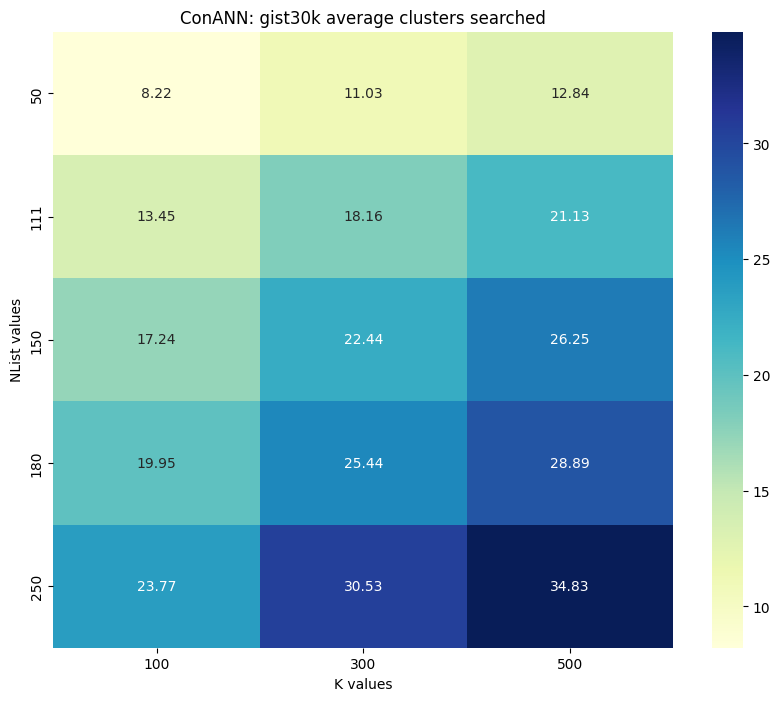

In [32]:
import seaborn as sns

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
sns.heatmap(results_conann_avg, annot=True, fmt=".2f", xticklabels=range_k, yticklabels=range_nlist, cmap="YlGnBu")
plt.xlabel('K values')
plt.ylabel('NList values')
plt.title(f"ConANN: {DATASET} average clusters searched")
plt.show()

In [33]:
results_conann_validity = np.empty(shape=(len(range_nlist), len(range_k)))
# for nlist, k in [(n, k) for n in range_nlist for k in range_k]:
for i in range(0, len(range_nlist)):
    for j in range(0, len(range_k)):
        fnrs = import_from_logs("ConANN", "error", DATASET, range_nlist[i], range_k[j], CALIB_SIZE)
        results_conann_validity[i][j] = np.average(fnrs)

In [34]:
display(results_conann_validity)

array([[0.10424   , 0.09852666, 0.10552   ],
       [0.102     , 0.09956667, 0.097552  ],
       [0.09976   , 0.10073333, 0.100508  ],
       [0.09808   , 0.1021    , 0.101916  ],
       [0.10072   , 0.09984666, 0.101456  ]])

In [10]:
results_conann_no_threshold = np.empty(shape=(len(range_nlist), len(range_k)))
# for nlist, k in [(n, k) for n in range_nlist for k in range_k]:
for i in range(0, len(range_nlist)):
    for j in range(0, len(range_k)):
        clusters_searched = import_from_logs("ConANN", "efficiency", DATASET, range_nlist[i], range_k[j])
        results_conann_no_threshold[i][j] = np.count_nonzero(clusters_searched == -1)

In [11]:
display(results_conann_no_threshold)

array([[202., 178., 149.],
       [159., 109.,  66.],
       [169.,  98.,  30.],
       [139.,  96.,  39.],
       [151.,  65.,  33.]])

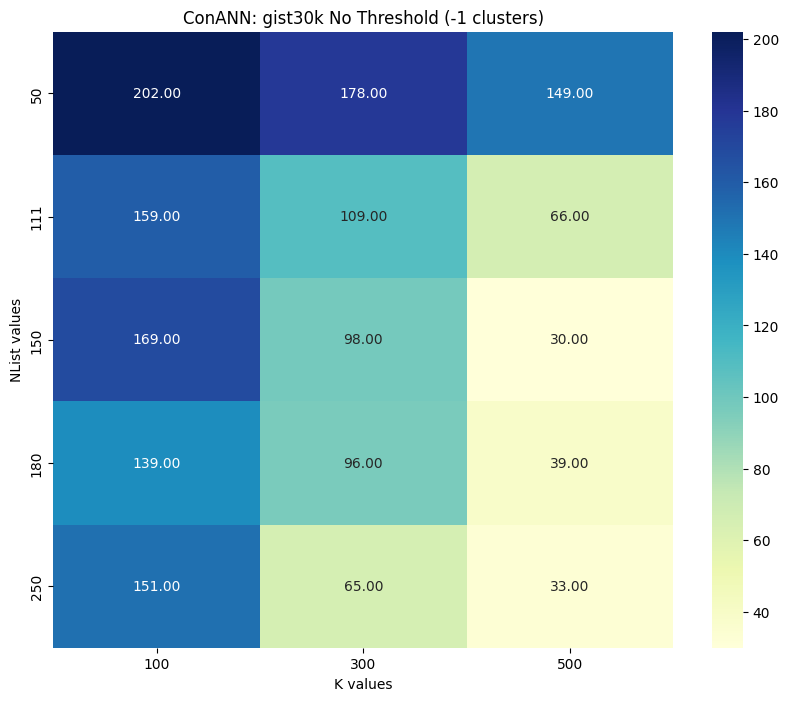

In [12]:
import seaborn as sns

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
sns.heatmap(results_conann_no_threshold, annot=True, fmt=".2f", xticklabels=range_k, yticklabels=range_nlist, cmap="YlGnBu")
plt.xlabel('K values')
plt.ylabel('NList values')
plt.title(f'ConANN: {DATASET} No Threshold (-1 clusters)')
plt.show()

## results faiss

In [14]:
results_faiss = np.empty(shape=(len(range_nlist), len(range_k)))
# for nlist, k in [(n, k) for n in range_nlist for k in range_k]:
for i in range(0, len(range_nlist)):
    for j in range(0, len(range_k)):
        clusters_searched = import_from_logs("Faiss", "efficiency", DATASET, range_nlist[i], range_k[j])
        results_faiss[i][j] = clusters_searched[0]

In [15]:
display(results_faiss)

array([[ 9., 11., 12.],
       [15., 18., 20.],
       [18., 22., 25.],
       [20., 25., 28.],
       [24., 31., 35.]])

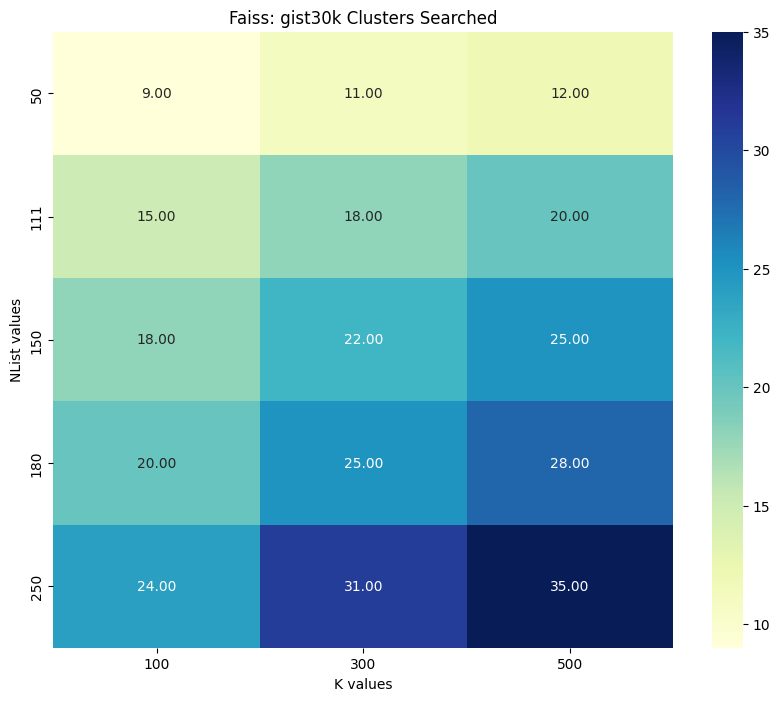

In [16]:
import seaborn as sns

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
sns.heatmap(results_faiss, annot=True, fmt=".2f", xticklabels=range_k, yticklabels=range_nlist, cmap="YlGnBu")
plt.xlabel('K values')
plt.ylabel('NList values')
plt.title(f'Faiss: {DATASET} Clusters Searched')
plt.show()

## compare

In [35]:
comparison = (results_conann_avg - results_faiss) / results_faiss * 100

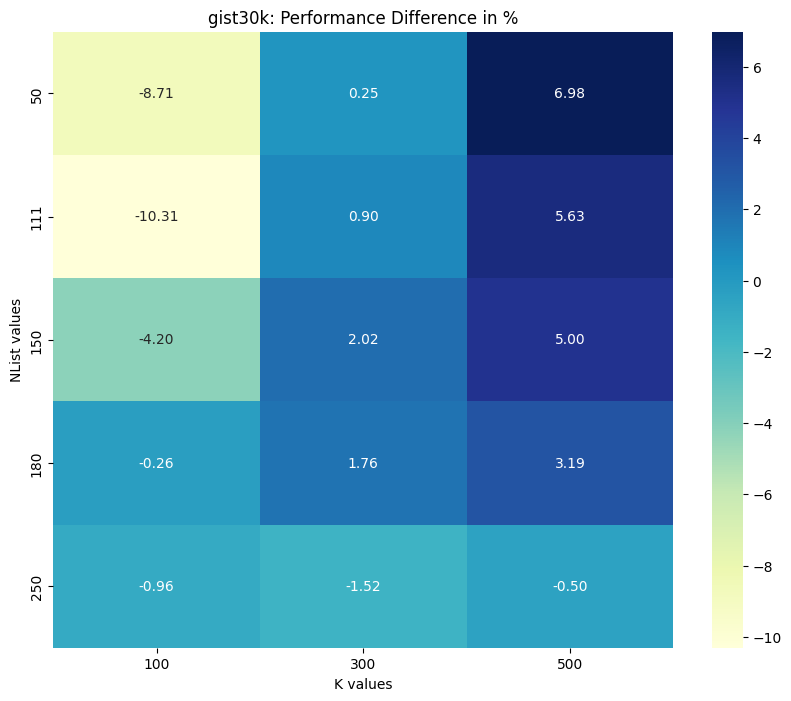

In [36]:
import seaborn as sns

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
sns.heatmap(comparison, annot=True, fmt=".2f", xticklabels=range_k, yticklabels=range_nlist, cmap="YlGnBu")
plt.xlabel('K values')
plt.ylabel('NList values')
plt.title(f'{DATASET}: Performance Difference in %')
plt.show()

# Experiment 2: nlist and calib

In [18]:
results_conann_calib = np.empty(shape=(len(range_nlist), len(range_calib)))
for i in range(0, len(range_nlist)):
    for j in range(0, len(range_calib)):
        clusters_searched = import_from_logs("ConANN", "efficiency", DATASET, range_nlist[i], 100, range_calib[j])
        results_conann_calib[i][j] = np.average(clusters_searched)

In [19]:
display(results_conann_calib)

array([[15.45      , 15.30133333, 15.4484    , 15.47742857, 15.60888889],
       [27.844     , 27.75866667, 28.4208    , 28.68828571, 28.51533333],
       [36.65      , 35.71466667, 36.2064    , 36.59428571, 36.20133333],
       [42.51      , 41.43333333, 42.342     , 42.16085714, 42.74711111],
       [51.754     , 51.27666667, 52.1208    , 51.64828571, 51.60288889]])

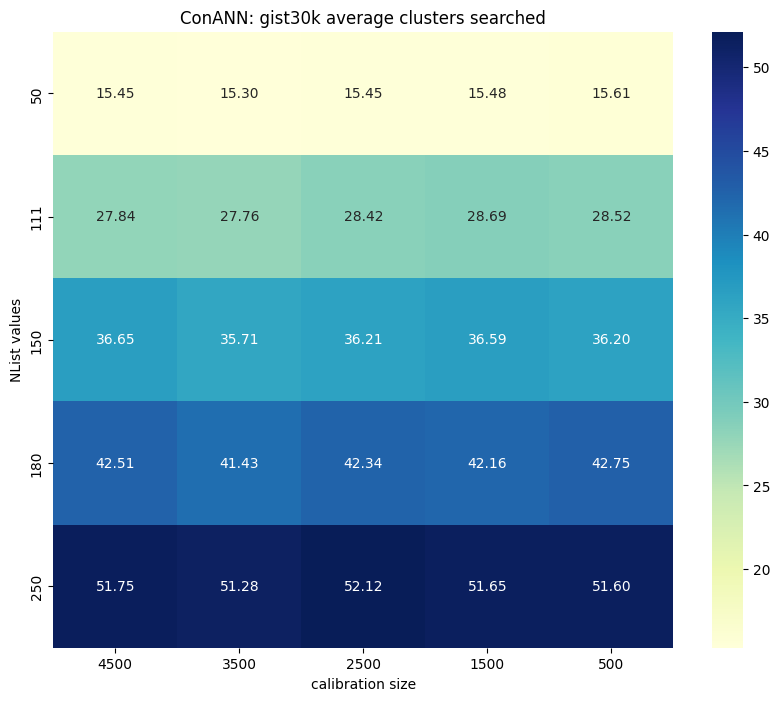

In [28]:
import seaborn as sns

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
sns.heatmap(results_conann_calib, annot=True, fmt=".2f", xticklabels=[int(x * 5000) for x in range_calib], yticklabels=range_nlist, cmap="YlGnBu")
plt.xlabel('calibration size')
plt.ylabel('NList values')
plt.title(f'ConANN: {DATASET} average clusters searched')
plt.show()

In [29]:
results_conann_calib_no_threshold = np.empty(shape=(len(range_nlist), len(range_calib)))
for i in range(0, len(range_nlist)):
    for j in range(0, len(range_calib)):
        clusters_searched = import_from_logs("ConANN", "efficiency", DATASET, range_nlist[i], 100, range_calib[j])
        results_conann_calib_no_threshold[i][j] = np.count_nonzero(clusters_searched == -1)

In [30]:
display(results_conann_calib_no_threshold)

array([[ 37., 124., 202., 273., 300.],
       [ 43., 114., 159., 204., 262.],
       [ 30., 112., 169., 219., 297.],
       [ 30.,  98., 139., 205., 224.],
       [ 26.,  94., 151., 212., 257.]])

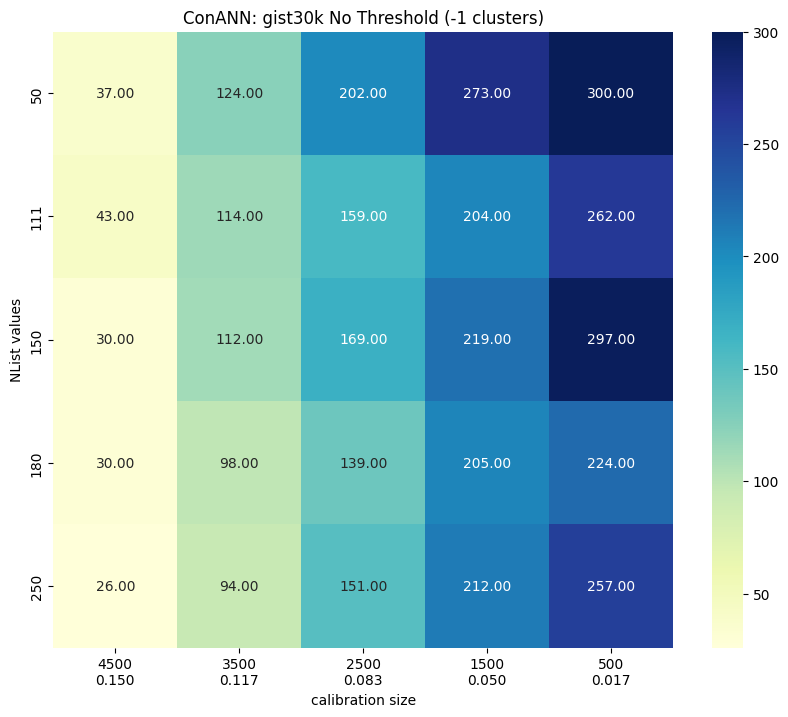

In [31]:
import seaborn as sns

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
sns.heatmap(results_conann_calib_no_threshold, annot=True, fmt=".2f", xticklabels=[f"{int(x * 5000)}\n{float(x*5000/30000):.3f}" for x in range_calib], yticklabels=range_nlist, cmap="YlGnBu")
plt.xlabel('calibration size')
plt.ylabel('NList values')
plt.title(f'ConANN: {DATASET} No Threshold (-1 clusters)')
plt.show()

In [32]:
validity_conann_calib = np.empty(shape=(len(range_nlist), len(range_calib)))
for i in range(0, len(range_nlist)):
    for j in range(0, len(range_calib)):
        fnrs = import_from_logs("ConANN", "error", DATASET, range_nlist[i], 100, range_calib[j])
        validity_conann_calib[i][j] = np.average(fnrs)

In [33]:
display(validity_conann_calib)

array([[0.09052   , 0.09959333, 0.09658   , 0.09395714, 0.08094667],
       [0.10602   , 0.10446667, 0.088568  , 0.07983143, 0.07940222],
       [0.08608   , 0.11005333, 0.10126   , 0.09061143, 0.09517333],
       [0.09984   , 0.10524   , 0.091044  , 0.09397429, 0.07432889],
       [0.085     , 0.09866   , 0.0917    , 0.09422286, 0.08814667]])

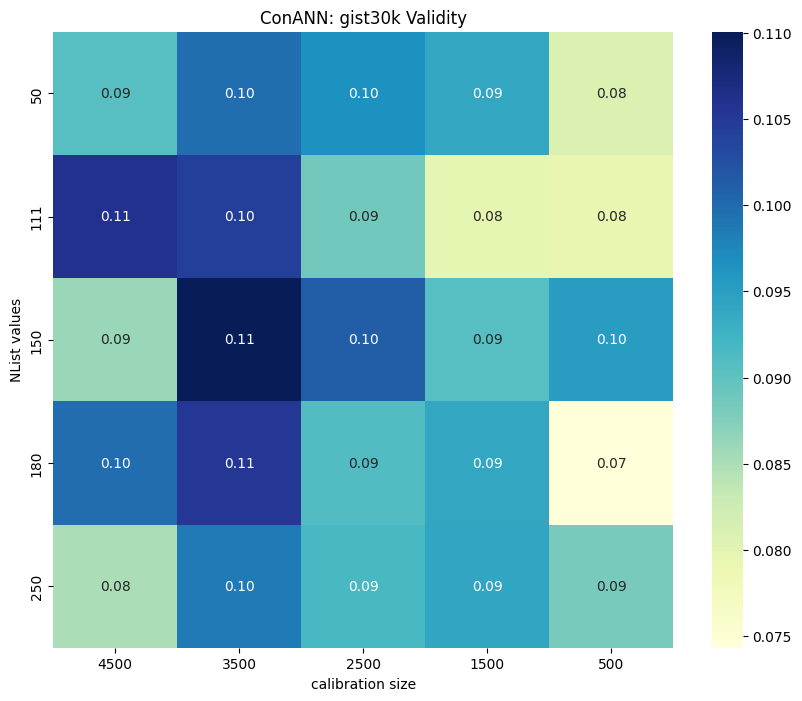

In [34]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
sns.heatmap(validity_conann_calib, annot=True, fmt=".2f", xticklabels=[int(x * 5000) for x in range_calib], yticklabels=range_nlist, cmap="YlGnBu")
plt.xlabel('calibration size')
plt.ylabel('NList values')
plt.title(f'ConANN: {DATASET} Validity')
plt.show()
